# Baseline of the first ML Model: TF-IDF

                    TEXT
                      │
                      ▼
                TF-IDF
                      │
                      ▼
          Logistic Regression
                      │
                      ▼
                 PREDICTION
                      │
          ┌───────────┼───────────┐
          ▼           ▼           ▼
       Accuracy    Precision      Recall
                                  │
                                  ▼
                                  F1

# 1. Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# 2. Load dataset

Even though we've already worked with the data in the previous notebook, a notebook must be reproducible on its own.

In [3]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

dataset = load_dataset("fancyzhx/yelp_polarity")

df_train = dataset["train"].to_pandas()
df_test = dataset["test"].to_pandas()

from src.preprocessing import clean_text

df_train["text"] = df_train["text"].apply(clean_text)
df_test["text"] = df_test["text"].apply(clean_text)

# 3. Train / Validation / Test split

In [4]:
from sklearn.model_selection import train_test_split

X = df_train["text"]
y = df_train["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_test = df_test["text"]
y_test = df_test["label"]

print("Training:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Training: 448000
Validation: 112000
Test: 38000


# 4. TF-IDF

TF  - Term Frequency               (frequent words)
IDF - Inverse Document Frequency   (rare words)

Review
   │
   ▼
TF-IDF
   │
   ▼
numerical feature vector
   │
   ▼
Logistic Regression

## Build the TF-IDF

Start with a baseline configuration, without finding firstly the max score

In [5]:
tfidf = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

- ngram_range=(1, 2) 

Means both unigram and bigram are used.
For example "good" and "not good". They have very different meanings.

- min_df=2 

Ignore terms present in only one document

- max_df=0.95

Ignore terms present in 95% ore more documents

## Text transformation

In [6]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_val_tfidf = tfidf.transform(X_val)

X_test_tfidf = tfidf.transform(X_test)

On the training `fit_transform()` is performed
On the validation/test `transform()` is performed

Never do `fit_transform()` on the validation or test. 

Because the TF-IDF vocabulary must be built solely on the training set.
Otherwise, we would have data leakage.

# 5 TF-IDF matrix inspection

In [7]:
print("Train shape:", X_train_tfidf.shape)
print("Validation shape:", X_val_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

Train shape: (448000, 2049634)
Validation shape: (112000, 2049634)
Test shape: (38000, 2049634)


## Let's see how sparse the matrix is

In [8]:
print("Matrix type:", type(X_train_tfidf))
print("Non-zero values:", X_train_tfidf.nnz)

total_values = (
    X_train_tfidf.shape[0] *
    X_train_tfidf.shape[1]
)

sparsity = 1 - (X_train_tfidf.nnz / total_values)

print(f"Sparsity: {sparsity:.4%}")

Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Non-zero values: 87585608
Sparsity: 99.9905%


It ends up with very high sparsity.

That is why the matrix should not be converted into a regular dense NumPy array.

# 6. Logistic Regression

In [7]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

# 7. Validation predictions

In [8]:
y_val_pred = model.predict(X_val_tfidf)
y_test_pred = model.predict(X_test_tfidf)

# 8. Evaluation metrics

In [9]:
def evaluate_model(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred)
    }


In [10]:
val_metrics = evaluate_model(y_val, y_val_pred)

val_metrics

{'accuracy': 0.9493571428571429,
 'precision': 0.950048288442966,
 'recall': 0.9485892857142857,
 'f1': 0.9493182264953446}

# 9. Classification report

In [11]:
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=["negative", "positive"]
    )
)

              precision    recall  f1-score   support

    negative       0.95      0.95      0.95     56000
    positive       0.95      0.95      0.95     56000

    accuracy                           0.95    112000
   macro avg       0.95      0.95      0.95    112000
weighted avg       0.95      0.95      0.95    112000



# 10. Confusion Matrix

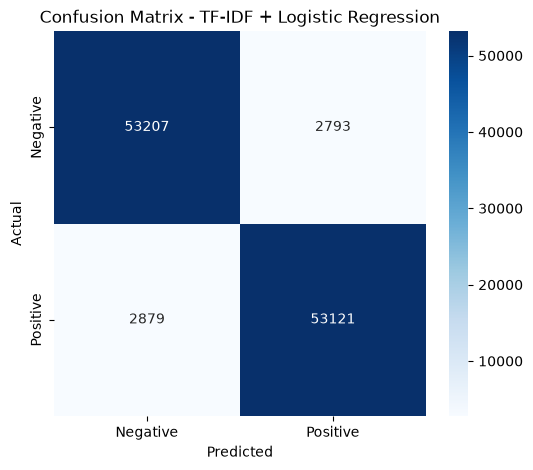

[[53207  2793]
 [ 2879 53121]]


In [12]:
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Confusion Matrix - TF-IDF + Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print(cm)

# 11. Manual predictions

In [13]:
examples = [
    "This restaurant was absolutely amazing!",
    "The food was terrible and the service was awful.",
    "I would definitely come back here again.",
    "Worst experience ever. I will never return."
]

example_tfidf = tfidf.transform(examples)

example_predictions = model.predict(example_tfidf)

example_probabilities = model.predict_proba(example_tfidf)

for text, prediction, probability in zip(
    examples,
    example_predictions,
    example_probabilities
):
    sentiment = "POSITIVE" if prediction == 1 else "NEGATIVE"
    confidence = probability[prediction]

    print(f"\nReview: {text}")
    print(f"Prediction: {sentiment}")
    print(f"Probability: {confidence:.2%}")


Review: This restaurant was absolutely amazing!
Prediction: POSITIVE
Probability: 97.68%

Review: The food was terrible and the service was awful.
Prediction: NEGATIVE
Probability: 100.00%

Review: I would definitely come back here again.
Prediction: POSITIVE
Probability: 99.57%

Review: Worst experience ever. I will never return.
Prediction: NEGATIVE
Probability: 99.99%


So far, we have:

TRAIN
448,000
   │
   ▼
TF-IDF fit
   │
   ▼
Logistic Regression
   │
   ▼
VALIDATION
112,000
   │
   ▼
metrics

The test:

TEST
38,000

remains closed.

Later, once we have definitively chosen and configured the baseline, we will use it for the final evaluation.

## Understanding the results

Great result. The baseline is already very strong. 🔥

Achieved:

Metric      Validation
Accuracy    *94.94%*
Precision   *95.00%*
Recall      *94.86%*
F1          *94.93%*

And TF-IDF produced:

- *448,000* documents
- *2,049,634* features
- *87,585,608* non-zero values
- *99.9905%* sparsity

This is exactly the behavior expected from a high-dimensional TF-IDF representation.

1. **Interpretation of the results**

The model is processing:

448,000 reviews
       │
       ▼
     TF-IDF
       │
       ▼
2,049,634 features
       │
       ▼
Logistic Regression
       │
       ▼
    94.94%

An *F1 score of ≈ 0.949* means that the baseline successfully classifies sentiment correctly in the vast majority of cases, maintaining a good balance between precision and recall.

And there’s one particularly positive aspect:

Precision = 95.00%
Recall    = 94.86%

These are practically *equivalent*.

So there isn't a model that, for example, does a great job recognizing positive sentiment but fails on negative sentiment.

2. **The sparsity is enormous, and that’s normal**

metrics:

2,049,634 features
87,585,608 non-zero
99.9905% sparse

It seems enormous, but that’s precisely why TfidfVectorizer uses a sparse matrix.

Imagine:

Review 1 → [0, 0, 0, 0, 0, 0, 0, 0, 0, 0.42, ...]
Review 2 → [0, 0.13, 0, 0, 0, 0, 0, 0, ...]
Review 3 → [0, 0, 0, 0.72, 0, 0, 0, ...]

Most of the values are zero.
Storing all those millions of zeros would be a huge waste.
That’s why it should never be done:

`X_train_tfidf.toarray()`

on the entire dataset.

3. **To avoid making the tuning right now**

if tempted to do: 

`GridSearchCV(...)`

and try to increase 94.94% to 95.20%

But now it is not the right time. 
First, it is important to understand how the model makes mistakes.

4. **About the confusion matrix**

TN = 53,207 → correctly classified negatives
FP = 2,793 → negatives incorrectly classified as positives
FN = 2,879 → positives incorrectly classified as negatives
TP = 53,121 → correctly classified positives

The total is:

53,207 + 2,793 + 2,879 + 53,121 = 112,000

so it matches the validation set perfectly.

Interesting observation: the errors are very balanced!

False Positives = 2,793
False Negatives = 2,879

This confirms what we saw from the metrics: the model is *not heavily biased* toward one class.

# 12. Error Analysis

In [21]:
val_probabilities = model.predict_proba(X_val_tfidf)

results = pd.DataFrame({
    "text": X_val.values,
    "true_label": y_val.values,
    "predicted_label": y_val_pred,
    "confidence": val_probabilities.max(axis=1)
})

errors = results[
    results["true_label"] != results["predicted_label"]
].copy()

print("Number of errors:", len(errors))

false_positives = errors[
    (errors["true_label"] == 0) &
    (errors["predicted_label"] == 1)
]

print("False positives:", len(false_positives))


false_negatives = errors[
    (errors["true_label"] == 1) &
    (errors["predicted_label"] == 0)
]

print("False negatives:", len(false_negatives))

Number of errors: 5672
False positives: 2793
False negatives: 2879


In [22]:
pd.set_option("display.max_colwidth", 500)
false_positives[["text", "true_label", "predicted_label"]].head(10)

,text,true_label,predicted_label
74,"Every thing in this club is amazing. The service, Dj and waiters are good but there is only one problem if they solved it, it will be one of the best clubs in las vegas the music is too too too laud. Im glad I'm not deaf after this night. I couldn't stay any longer.",0,1
79,"Walked over from the Cosmo to pick up some much needed coffee and breakfast for Hubs and I.\n\nThe staff was very friendly, area was clean and organized and prices were very high. \n\nI ordered 1 skinny grande mocha ($5.85) 1 grande pumpkin spice latte ($5.85 with soy milk extra charge of $0.75 added) small fruit bowl ($5.95), oatmeal ($5.) and a yogurt parfait ($5.95) The total was $31.73. \n\nThe coffees weren't good. My mocha didn't have much flavor and Hubs said his wasn't as good as he ...",0,1
108,"Be ready to wait when you come Madison East USCC. Often have to wait 45-60 minutes. When you finally get to see an agent, they are always very helpful, pleasant, and patient. The employees seem very well trained. One downfall they have, and I have experienced this many times, is that the agent cannot take care of everything at their computer terminal. For some reason they always need to \""""call-in\"""" some issues to the central office for some far-away person to perform a task for them. That ...",0,1
118,"This is a great Albertsons. Great location, friendly staff, reasonable price.\nWatch out. Be very careful when you purchase gift cards here, especially $500 Visa or AMEX gift cards.\nI bought a $500 Gift Card (GC) in October 2013. Within 2 hours, some one was able to use a duplicated gift card to purchase almost $500 worth of staff about 4 miles north of the store.\nI talked to the store Manager and he is aware of the problem. It could be an inside job. Someone open the package using steam a...",0,1
140,We have NEVER had a togo order that has been correct from here. EVER\n\nI am talking about 9-10 years worth...,0,1
270,"I've been coming here on a regular basis (1-2x/month minimum) for the past 5 years and I've never had to pay cover... until now. I've always loved this bar because of the \""""neighborhood bar\"""" atmosphere, and I've enjoyed the fact that it's within walking distance from my home, but with the recent changes to the happy hours, and now having to pay a cover, I'm thinking I'll start taking a cab to another bar...",0,1
286,"The tacos here are street style, which means that they are muy tiny. I have been here around 4 or 5 times and they are always overloaded with cilantro. Customer service is very good however.",0,1
319,"I haven't been at Le Finlandais in well over a decade, however, a last minute decision prompted us to attempt a spa experience without needing to drive too far from Montreal. There are many reasons why we haven't come back to this spa but since we've heard about how recent renovations made this place \""""so much better\"""" curiosity finally got the best of us... and we paid the price for it... literally.\n\nTHE GOOD\n\n- The place is visually appealing : If you're here early enough to experien...",0,1
440,"Food's decent - staff is generally friendly. The place is a little rough by US standards. Actually, it was a lot like places I went in the middle east in a number of ways. If you're squeamish about sparkling walls and counters, this probably isn't the place for you. If you're willing to overlook a bit to have some traditional middle east food, go for it - you should like it.",0,1
450,"I'm a huge fan of Radio Maria, but their Valentine's Day Dinner left a very bad taste in my mouth and it wasn't the food. Radio Maria is my favorite restaurant in Champaign. The food is top-notch and the atmosphere is one of a kind. But my wife and I had their Valentine's day menu this past weekend. The food was great, but not for the outrageous cost. It was $50/person plus drinks for a \""""tasting\"""" menu that wouldn't have filled up a mouse. Normally the value/price ratio is excellent. I al...

In [23]:
false_negatives[["text", "true_label", "predicted_label"]].head(10)

,text,true_label,predicted_label
32,"They start ON TIME. No wiggle room whatsover. We got our tickets torn, then, with a few minutes before showtime, we ducked into our respective restrooms. At no point prior had we seen flashing lights, nor announcement about PROMPT curtain. \n\nWe missed the opening number along with at least another dozen people. Once we were let in, there was still a constant stream of latecomings throughout the First Act. \n\nIs the show great? Yes. Should patrons be in their seats at Curtain Time. Yes. Ha...",1,0
44,"I didn't know food at one Pita Jungle could differ from another. I swore I would never return to this location after I witnessed an employee do something gross (sneezed in her palm, handled money, and then bare handed my pita), which I notified a manager of and it was rectified. Fast forward a couple of years. I return. Wow. The tofu at this location is fantastic. The Macro platter here is worth the drive from where I am and I would drive past 2 other Pita Jungles. Big fan. The server was re...",1,0
48,hmmm.. okay drausen nicht besonders einladend gewesen .. m\u00fcsste wohl mal ein bisschen .. in ordnung gebracht werden. Drinnen das selbe bild ich hatte einen fensterplatz und auf der fensterbank lagen neben der eingestaubten pflanze mehrere tote fliegen ?! und die scheiben naja puhh.\nBedienung war nett und freundlich getr\u00e4nke waren flott da.\ndie vorspei\u00dfe platte naja.. leiber finger weg die war echt doof !!!\ndaf\u00fcr war das vegetarische hauptgericht mit aubergine echt der ...,1,0
60,"Pisces is a place that I would probably only go to for lunch to take advantage of their All You Can Eat sushi. It is a nice atmosphere inside, and the perk is it is right across the street from where I work. \n\nI do have to say, their Garlic Noodles are so BOMB!!! The past few times I have gone there, I must confess that I order not one, but TWO plates of the Garlic Noodles. I feel that sometimes the service is slacking a bit. The times that I have gone there, it did not seem that busy, but...",1,0
67,"First time I ordered out from here for work. Drawback.. the salads aren't pre tossed in the dressing. Obviously to keep from being soggy upon pick up but the dressing they supply is more than what they would toss with if you ate on site. Unfortunately I trusted the portions they gave me would recreate the \""""on site\"""" salad and I ended up drowning my poor salad into a soggy mess. Also I had to tell the boy packing the order not to put the burgers in with the salads. Hello? Isn't that \""""Wor...",1,0
94,Pretty decent! I definitely think there are better soup places here in town but this place is pretty good. I think I was a little turned off because my skewer was cold but the service is astounding!,1,0
156,"Grand canyon brewery.. need I say more? \n\nOK I will! Supports local breweries I saw at least 5 different Arizona breweries on the menu! Drink local! Comedy club is passable at best, shit seating and the host thought he was the main event, but the local talent was OK, I guess? Travis?! was the most memorable, lots of current politics/events that were goin on. Review is a bit old..",1,0
253,"A very nice if somewhat simple hotel. \nThe room as fine with nice furnishings, a very comfortable bed and a great bathroom. Sadly my king room had an outlook of nothing and as almost no sunlight came through the window it was almost like being in a windowless room. \nThe free minibar is a nice touch, but a shame there are no alcoholic beverages in the room. Ordered room service which was expensive, cold and plain accompanied with a boring selection of beers. Give this a miss if you stay. \n...",1,0
291,"The remodeling of this building was done extremely well, and I was extremely impressed when first seeing the interior. But, the food is terrible, and unfortunately, I doubt I will ever go back. \n\nThe staff is friendly, and I really want them to succeed, but I think the writing is already on the wall

**What patterns to look for**

- Sarcasm
- Denials
- Mixed reviews
- Contrasting sentiment
- Context
- Positive words used in a negative review
- Negative words used in a positive review

## Confidence analysis

In [32]:
# more confident mistakes

errors.sort_values(
    "confidence",
    ascending=False
)[
    ["text", "true_label", "predicted_label", "confidence"]
].head(10)

,text,true_label,predicted_label,confidence
42996,Great,0,1,1.000000
99253,Great food great staff and great atmosphere.,0,1,0.999970
8803,"The Richardsons restaurants are fun, unique and delicious...have always been my favorite.",0,1,0.999195
20211,"I went here for lunch today for the first time. I typically just come here for the macaroons but today I wanted something different. This rating is solely based off if the food and not the customer service. I ordered the daily special and my coworker ordered the mozzarella, tomato, basil sandwich. The food was really good. This is what happened: I called in the order for pick up for me and a coworker and everything seemed ok. They never gave me the total amount just that they would see me th...",1,0,0.998866
66753,Awesome place. Friendly staff. Good prices. Oh and their vape selection is amazing even compared to Cali. White Cloud definitely knows their stuff,0,1,0.998757
110890,"I love Mimi's Caf\u00e9... I do, but I \""""gadda\"""" say the following, I don't have to, I \""""gadda\"""". My wife and I went there for dinner... the \""""Hi there\"""" greeting rapidly changed to an annoyed face when we requested a booth that wasn't in the area first chosen by the waitress... we hadn't sit down for 2 minutes that we were already being asked for the drinks... we politely asked for a little more time... our order was taken, the drinks and the food were delivered. We hadn't got one bit...",1,0,0.998681
76200,"Really tasty and affordable diner food. I do prefer this to most chain diners.\n\nIt's not the ABSOLUTE best but they have a nice variety.\n\nI've had the Cajun prime rib once and the fried chicken dinner once.\n\nThe prime rib is pretty thin. I wouldn't get it again but the seasoning was good. Their mashed potatoes are really good.\n\nThe fried chicken was really good when I got it. It has a nice crust, is seasoned well, and it comes with 4-5 pieces. I think it's half a chicken. Oh & 2 side...",0,1,0.998424
23018,"They've changed the menu to Southwestern and have discontinued the tequila specials. Skip it!\n\n\n\n\n\n\nTasty Gringo style tacos, and amazing drink specials. This is probably that late night place you're looking for if you grew up in LA or San Diego. They make real guac, serve up hefty margaritas, and it's all at only-in-vegas prices. If you're losing and want to party, definitely come here. This is also a great post-club move if you want some grub. The food is freshly prepared and while ...",0,1,0.998156
58630,"Great place! Awesome food and atmosphere, try the short rib tacos! Only complaint, they discontinued their happy hour menu for food. But other than that, great place to eat!",0,1,0.998003
71165,"I went here because I really wanted potato skins and I had an awful experience at Gallaghers and left. The food here was not bad,but overpriced, and the service was above average. I would go back, but would probably prefer happy hour :-)",1,0,0.996986


In [33]:
# less confident mistakes

errors.sort_values(
    "confidence",
    ascending=True
)[
    ["text", "true_label", "predicted_label", "confidence"]
].head(10)

,text,true_label,predicted_label,confidence
44419,Wow amazing Rooftop open air view....great for pictures. .. However Bouncer rude. .. drinks weak. .. Music Bleh.,1,0,0.500003
32693,"This was my first time here and I came to give it a try. First of all- don't try and use the 50% off for checking in they don't honor it. The food was O.K. At best. I was really just looking for a cool place to hangout near my house and have a few drinks but the atmosphere isn't great either. On a plus, happy hour goes from 2-7 everyday.....",0,1,0.500005
29360,"As casinos go, this one really has little going for it. It is away from downtown and the strip so you won't walk there. It is like walking into a lit box of cigarettes, the carpet and decor is old and worn, and in general the people there do not look happy.\n\nI do enjoy Jerry's deli for cheap, decent comfort food though which is why it gets 2 stars.",0,1,0.500051
80234,"I would have liked to rate them well as they are a typical mom and pop store unfortunately all the 3 times I have been there the food is passable at the best. The air is also thick with burnt wok oil which ruins ones hunger if you sit around for too long(bad ventilation).\n\nThey do have wonderful service and generous portions, but that has never been a redeeming feature for restaurants.\n\nSo far I have tried the Kung pao, the Singapore noodle and the firecracker",0,1,0.500085
11293,"The menu is good. The food is the same as their other property's just more money. Fish tacos good, salads good. Prime rib dip, not prime at all, fries are to skinny & don't stay hot. Eat at the counter its quicker. Martin 6-7-13",0,1,0.500087
107707,"This is where I got my pet rat, Splinter, she was a quality rat.",1,0,0.500363
104622,Yes definite tourist trap. The stuff was ridiculously expensive. The staff was friendly but that still doesn't make my wallet any happier. Go find some other place. Thank you Las Vegas for jacking up the price of food.,0,1,0.500374
101314,"Found this place via Living Social and have been here several times since. It's a classic Spanish Tapas joint. It gets busy on the weekends when they have live entertainment and Flamenco dancers on the stage. When that happens, it can get loud and crowded in the lower seating area next to the stage. We sat there once and didn't like it....it was uncomfortable and The Better Half and I couldn't have a conversation because it was too loud. It's worth checking out at least once though.\n\nOver ...",0,1,0.500381
34074,"People here are one of the following: toothless, heavy smokers outside of their room on the balcony talking loud, people who likely live in a motorhome or trailer and are living the high-life here, or about 40 aging men softball players. Then, there is me -- a cratchedly grumbly snooty hotel-stayer.\n\nWhat it is: cheap; value-priced; great location next to the Fashion Square mall near Old Town Scottsdale; good for travelers; partiers, large groups needing a low-cost option.\n\nWhat it is NO...",0,1,0.500387
110937,"Kiku ... maybe it's my fault that I used to love you, and now we're just friends. It could be that I ordered a measley eel/cucumber roll, and maybe you didn't find that fancy enough. Or a Philadelphia (that you so endearingly renamed Shadyside). In my Dynamite, you forgot my spicy mayo (maybe that's for the better, but you did kindly garnish the plate with a bit). \n\nAll three of my rolls, it seems you forgot some of the fish. It hurts my heart; your fish is so fresh ... when you put it in ...",1,0,0.500504


In [30]:
# false positive

false_positives = errors[
    (errors["true_label"] == 0) &
    (errors["predicted_label"] == 1)
]

print("False positives:", len(false_positives))
false_positives[
    ["text", "true_label", "predicted_label", "confidence"]
].head(10)

False positives: 2793


,text,true_label,predicted_label,confidence
74,"Every thing in this club is amazing. The service, Dj and waiters are good but there is only one problem if they solved it, it will be one of the best clubs in las vegas the music is too too too laud. Im glad I'm not deaf after this night. I couldn't stay any longer.",0,1,0.818157
79,"Walked over from the Cosmo to pick up some much needed coffee and breakfast for Hubs and I.\n\nThe staff was very friendly, area was clean and organized and prices were very high. \n\nI ordered 1 skinny grande mocha ($5.85) 1 grande pumpkin spice latte ($5.85 with soy milk extra charge of $0.75 added) small fruit bowl ($5.95), oatmeal ($5.) and a yogurt parfait ($5.95) The total was $31.73. \n\nThe coffees weren't good. My mocha didn't have much flavor and Hubs said his wasn't as good as he ...",0,1,0.613597
108,"Be ready to wait when you come Madison East USCC. Often have to wait 45-60 minutes. When you finally get to see an agent, they are always very helpful, pleasant, and patient. The employees seem very well trained. One downfall they have, and I have experienced this many times, is that the agent cannot take care of everything at their computer terminal. For some reason they always need to \""""call-in\"""" some issues to the central office for some far-away person to perform a task for them. That ...",0,1,0.544113
118,"This is a great Albertsons. Great location, friendly staff, reasonable price.\nWatch out. Be very careful when you purchase gift cards here, especially $500 Visa or AMEX gift cards.\nI bought a $500 Gift Card (GC) in October 2013. Within 2 hours, some one was able to use a duplicated gift card to purchase almost $500 worth of staff about 4 miles north of the store.\nI talked to the store Manager and he is aware of the problem. It could be an inside job. Someone open the package using steam a...",0,1,0.715979
140,We have NEVER had a togo order that has been correct from here. EVER\n\nI am talking about 9-10 years worth...,0,1,0.718372
270,"I've been coming here on a regular basis (1-2x/month minimum) for the past 5 years and I've never had to pay cover... until now. I've always loved this bar because of the \""""neighborhood bar\"""" atmosphere, and I've enjoyed the fact that it's within walking distance from my home, but with the recent changes to the happy hours, and now having to pay a cover, I'm thinking I'll start taking a cab to another bar...",0,1,0.809674
286,"The tacos here are street style, which means that they are muy tiny. I have been here around 4 or 5 times and they are always overloaded with cilantro. Customer service is very good however.",0,1,0.766445
319,"I haven't been at Le Finlandais in well over a decade, however, a last minute decision prompted us to attempt a spa experience without needing to drive too far from Montreal. There are many reasons why we haven't come back to this spa but since we've heard about how recent renovations made this place \""""so much better\"""" curiosity finally got the best of us... and we paid the price for it... literally.\n\nTHE GOOD\n\n- The place is visually appealing : If you're here early enough to experien...",0,1,0.500637
440,"Food's decent - staff is generally friendly. The place is a little rough by US standards. Actually, it was a lot like places I went in the middle east in a number of ways. If you're squeamish about sparkling walls and counters, this probably isn't the place for you. If you're willing to overlook a bit to have some traditional middle east food, go for it - you should like it.",0,1,0.704964
450,"I'm a huge fan of Radio Maria, but their Valentine's Day Dinner left a very bad taste in my mouth and it wasn't the food. Radio Maria is my favorite restaurant in Champaign. The food is top-notch and the atmosphere is one of a kind. But my wife and I had their Valentine's day menu this past weekend. The food was great, but not for the outrageous cost. It was $50/person plus drinks for a \""""tasting\"""" men

In [31]:
# false negative

false_negatives = errors[
    (errors["true_label"] == 1) &
    (errors["predicted_label"] == 0)
]

print("False negatives:", len(false_negatives))
false_negatives[
    ["text", "true_label", "predicted_label", "confidence"]
].head(10)

False negatives: 2879


,text,true_label,predicted_label,confidence
32,"They start ON TIME. No wiggle room whatsover. We got our tickets torn, then, with a few minutes before showtime, we ducked into our respective restrooms. At no point prior had we seen flashing lights, nor announcement about PROMPT curtain. \n\nWe missed the opening number along with at least another dozen people. Once we were let in, there was still a constant stream of latecomings throughout the First Act. \n\nIs the show great? Yes. Should patrons be in their seats at Curtain Time. Yes. Ha...",1,0,0.884115
44,"I didn't know food at one Pita Jungle could differ from another. I swore I would never return to this location after I witnessed an employee do something gross (sneezed in her palm, handled money, and then bare handed my pita), which I notified a manager of and it was rectified. Fast forward a couple of years. I return. Wow. The tofu at this location is fantastic. The Macro platter here is worth the drive from where I am and I would drive past 2 other Pita Jungles. Big fan. The server was re...",1,0,0.649852
48,hmmm.. okay drausen nicht besonders einladend gewesen .. m\u00fcsste wohl mal ein bisschen .. in ordnung gebracht werden. Drinnen das selbe bild ich hatte einen fensterplatz und auf der fensterbank lagen neben der eingestaubten pflanze mehrere tote fliegen ?! und die scheiben naja puhh.\nBedienung war nett und freundlich getr\u00e4nke waren flott da.\ndie vorspei\u00dfe platte naja.. leiber finger weg die war echt doof !!!\ndaf\u00fcr war das vegetarische hauptgericht mit aubergine echt der ...,1,0,0.641251
60,"Pisces is a place that I would probably only go to for lunch to take advantage of their All You Can Eat sushi. It is a nice atmosphere inside, and the perk is it is right across the street from where I work. \n\nI do have to say, their Garlic Noodles are so BOMB!!! The past few times I have gone there, I must confess that I order not one, but TWO plates of the Garlic Noodles. I feel that sometimes the service is slacking a bit. The times that I have gone there, it did not seem that busy, but...",1,0,0.652028
67,"First time I ordered out from here for work. Drawback.. the salads aren't pre tossed in the dressing. Obviously to keep from being soggy upon pick up but the dressing they supply is more than what they would toss with if you ate on site. Unfortunately I trusted the portions they gave me would recreate the \""""on site\"""" salad and I ended up drowning my poor salad into a soggy mess. Also I had to tell the boy packing the order not to put the burgers in with the salads. Hello? Isn't that \""""Wor...",1,0,0.977045
94,Pretty decent! I definitely think there are better soup places here in town but this place is pretty good. I think I was a little turned off because my skewer was cold but the service is astounding!,1,0,0.674288
156,"Grand canyon brewery.. need I say more? \n\nOK I will! Supports local breweries I saw at least 5 different Arizona breweries on the menu! Drink local! Comedy club is passable at best, shit seating and the host thought he was the main event, but the local talent was OK, I guess? Travis?! was the most memorable, lots of current politics/events that were goin on. Review is a bit old..",1,0,0.784996
253,"A very nice if somewhat simple hotel. \nThe room as fine with nice furnishings, a very comfortable bed and a great bathroom. Sadly my king room had an outlook of nothing and as almost no sunlight came through the window it was almost like being in a windowless room. \nThe free minibar is a nice touch, but a shame there are no alcoholic beverages in the room. Ordered room service which was expensive, cold and plain accompanied with a boring selection of beers. Give this a miss if you stay. \n...",1,0,0.631630
291,"The remodeling of this building was done extremely well, and I was extremely impressed when first seeing the interior. But, the food is terrible, and unfortunately, I doubt I will ever go back. \n\nThe staff is friendly

1. Errors on **overall meaning**

The most obvious errors are almost all cases where the review contains many strongly positive words, but the overall sentiment is negative.

For example:

*“Great food, great staff, and great atmosphere.”*

The model sees *“great,” “food,” “staff,”* and *“atmosphere”* and essentially says:

`POSITIVE 99.997%`

but the label is `0`.

This is an excellent example of a **limitation of TF-IDF + Logistic Regression:** the model is very good at learning associations between words and sentiment, but it struggles when it comes to understanding the *overall meaning* of the sentence or review.

2. The case: **mixed reviews**

Take a look at this one:

*“Great place! Awesome food and atmosphere… Only complaint: they discontinued their happy hour menu…”*

The model:

`NEGATIVE → POSITIVE`
`confidence = 99.8%`

Why?

It probably learned something like:

*great*       → positive
*awesome*     → positive
*food*        → positive
*atmosphere*  → positive

and doesn’t really understand that:

*Only complaint...*

introduces a negative element.

3. The case: **context/sarcasm**

This one:

*“They’ve changed the menu ... Skip it! ... Tasty ... amazing ... great ...”*

is classified as:

`TRUE: NEGATIVE`
`PREDICTED: POSITIVE`
`confidence: 99.8%`

This is exactly the kind of problem we want to highlight in the project.

The model doesn’t “read” the review the way a human would.

It essentially does:

`words → weights → classification`

rather than:

`text → context → meaning → sentiment`

4. Errors at a **confidence level of ~0.50** are completely different

Here we have cases like:

*“Wow, amazing rooftop... However, the bouncer was rude... drinks were weak... Music: bleh.”*

The model:

`POSITIVE`
`50.0003%`

This is an *uncertain* model.

And it makes sense: the review contains the following at the same time:

*amazing*
*great*
+
*rude*
*weak*
*bleh*

The model is essentially saying:

“There are both positive and negative signals; I’m not sure which one prevails.”

This is a very different situation from the error:

POSITIVE 99.99%

5. High level error distinction identified

Therefore the errors could be classified into at least two categories:

**A. High-confidence errors**
`confidence ≈ 0.99+`

The model is **very confident** but gets it **wrong**.

Possible causes:

- strongly polarized words;
- mixed reviews;
- negation;
- context;
- sarcasm;
- sentiment expressed in the final sentence;
- contrast between different aspects.

**B. Low-confidence errors**
`confidence ≈ 0.50`

The model is **uncertain**.

These are often reviews that are genuinely ambiguous or have mixed sentiment.

6. Another insight: the context issue is in both directions

Look at this:

*“The remodeling … was done extremely well … extremely impressed … But, the food is terrible…”*

The model:

`TRUE: POSITIVE`
`PREDICTED: NEGATIVE`
`confidence: 99.0%`

Here, the opposite happens.

The first parts are positive, but the model focuses heavily on the strong signal:

*food*
*terrible*
*never go back*
*fail*

and concludes that the sentiment is negative.

So we have a *compositionality/context* issue in both directions.

7. And this brings directly to **DistilBERT**

Now the reason why the roadmap looks like this:

TF-IDF + Logistic Regression
              ↓
         Error Analysis
              ↓
          DistilBERT

becomes much clearer.

DistilBERT is introduced to see if a Transformer model can handle these specific cases better:

*“Great food, but terrible service.”*

*“Not the best restaurant I’ve visited.”*

*“I expected it to be bad, but it was amazing.”*

*“Great atmosphere. However, the food was terrible.”*

The Transformer has a much greater ability to utilize the **context** of words in the sequence, whereas our TF-IDF baseline represents the text primarily through terms and their weights.

8. An Interesting Note on *Labels*

You also found something worth noting:

*“Great”*
`label = 0`

This seems surprising.

We shouldn’t automatically conclude that the dataset is incorrect. There could be an explanation related to how *Yelp Polarity* is constructed and to the original reviews.

For the project, however, this raises another interesting question:

How much noise or ambiguity is present in the labels?

We shouldn’t manually correct these 5,672 reviews. It would be methodologically incorrect to alter the test/validation set based on our interpretation.


### Error Analysis: summary

The **TF-IDF + Logistic Regression** baseline achieved an *F1 score* of approximately `0.949` on the validation set.

The **confusion matrix** shows a balanced error distribution between the two classes, with `2,793` false positives and `2,879` false negatives.

An examination of misclassified reviews revealed two main types of errors:

1. **High-confidence errors:**
   the model is highly confident but fails on reviews containing mixed
   sentiment, contrasting statements, or strongly polarized words.

2. **Low-confidence errors:**
   the model is uncertain about reviews containing both positive and negative
   sentiment.

These errors highlight a **limitation of the bag-of-words representation:**
individual words can be strongly associated with a sentiment, while the
overall meaning of the review depends on context and interactions between
words.

**This motivates the comparison with a Transformer-based model such as DistilBERT.**

10. Now let’s wrap up the baseline phase

We have completed:

EDA                         ✅
Data cleaning               ✅
Train / Validation / Test   ✅
Duplicate analysis          ✅
TF-IDF                      ✅
Logistic Regression         ✅
Accuracy                    ✅
Precision                   ✅
Recall                      ✅
F1                          ✅
Confusion Matrix            ✅
Error Analysis              ✅

The next step is:

                    BASELINE
                       │
                       ▼
              ┌─────────────────┐
              │ TF-IDF + LR     │
              │ F1 = 0.9493     │
              └────────┬────────┘
                       │
                       ▼
                TRANSFORMERS
                       │
                       ▼
                 DistilBERT

# SAVE THE MODEL

In [34]:
import joblib
from pathlib import Path

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(model, MODEL_DIR / "tfidf_logistic_regression.pkl")

print("Model saved successfully.")

Model saved successfully.


In [37]:
# Save vectorized TF-IDF

joblib.dump(
    TfidfVectorizer,
    MODEL_DIR / "tfidf_vectorizer.pkl"
)

print("Vectorizer saved successfully.")

Vectorizer saved successfully.


In [ ]:
# When the notebook becomes too long, 
# the quickest way to find the right name of a vaiable is:

%whos

# LOAD THE MODEL 
(TO TEST THE CORRECTNESS OF SAVE/LOAD PROCEDURE) 

In [38]:
loaded_model = joblib.load(
    MODEL_DIR / "tfidf_logistic_regression.pkl"
)

loaded_vectorizer = joblib.load(
    MODEL_DIR / "tfidf_vectorizer.pkl"
)

print("Model and vectorizer loaded successfully.")

Model and vectorizer loaded successfully.


# TEST THE MODEL

In [ ]:
# testing a positive review

new_review = """
The food was absolutely amazing and the staff was incredibly friendly.
I would definitely come back!
"""

new_review_tfidf = tfidf.transform(
    [new_review]
)

prediction = loaded_model.predict(new_review_tfidf)[0]

probabilities = loaded_model.predict_proba(
    new_review_tfidf
)[0]

print("Prediction:", prediction)
print("Probability negative:", probabilities[0])
print("Probability positive:", probabilities[1])

Prediction: 1
Probability negative: 0.00041249033699830573
Probability positive: 0.9995875096630017


In [ ]:
# testing a negative review

new_review = """
The service was terrible and the food was cold.
The staff was rude and I will never come back.
"""

new_review_tfidf = loaded_vectorizer.transform(
    [new_review]
)

prediction = loaded_model.predict(
    new_review_tfidf
)[0]

probabilities = loaded_model.predict_proba(
    new_review_tfidf
)[0]

print("Prediction:", prediction)
print("Probability negative:", probabilities[0])
print("Probability positive:", probabilities[1])


sklearn.feature_extraction.text.TfidfVectorizer

# SAVE THE METRICS

In [42]:
import json

metrics = {
    "model": "TF-IDF + Logistic Regression",
    "accuracy": 0.9493571428571429,
    "precision": 0.950048288442966,
    "recall": 0.9485892857142857,
    "f1": 0.9493182264953446
}

with open(
    "../models/baseline_metrics.json",
    "w"
) as f:
    json.dump(metrics, f, indent=4)

print("Metrics saved.")

Metrics saved.


**What not do right now**

Trying to implement:
`src/train.py`
`src/predict.py`
`src/evaluate.py`

copying the code from this notebook.

First it is important to complete the ML cycle:

EDA
 ↓
Baseline
 ↓
Error Analysis
 ↓
Transformer
 ↓
Model Comparison
 ↓
Application

After that the best code could be refactored in `src/`

This prevents us from building a software structure around experiments that we might end up changing.